# Telecom Customer Churn: Exploratory Data Analysis and Baseline Modeling

## Objective

This notebook analyzes service, account, and demographic data for 7,043 telecom customers to identify patterns associated with customer churn. The analysis has Two goals:

1. assess and prepare the data for analysis.
3. build a classification model that can support targeted retention campaigns for churning customers in telecom companies.

> **Note:** This is an observational dataset. Differences in churn rates indicate associations, not necessarily causal effects.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(file_path)

sns.set_theme(style="whitegrid")
churn_palette = {"No": "#4C78A8", "Yes": "#E45756"}




In [2]:
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

display(df.head())
df.info()

Rows: 7043
Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

## Data quality assessment

The dataset contains 7,043 rows and 21 columns. The initial inspection identifies two issues that should be resolved before analysis:

- `SeniorCitizen` is stored as binary integers (`0` and `1`) while comparable indicator fields use `Yes` and `No`. Converting it to consistent labels improves readability.
- `TotalCharges` is stored as text rather than a numeric field, which prevents reliable numerical summaries and visualization.

The `customerID` field is an identifier rather than a feature that can be used by the model, so it should be removed after making sure there are no duplicates.

In [3]:
print("Duplicated rows:", df.duplicated().sum())
print("Duplicated customer IDs:", df["customerID"].duplicated().sum())
print("Unique customer IDs:", df["customerID"].nunique())

Duplicated rows: 0
Duplicated customer IDs: 0
Unique customer IDs: 7043


The dataset contains no duplicated rows or customer IDs. All 7,043 customer IDs are unique, so each row represents a distinct customer record.

In [4]:
# Drop customerID column as it is useless for analysis
df = df.drop("customerID", axis=1)

df = df.assign(
        SeniorCitizen=df["SeniorCitizen"].map({
            1: "Yes",
            0: "No"
        })
    )

text_columns = df.select_dtypes(include="str").columns

# Remove leading and trailing spaces
df[text_columns] = df[text_columns].apply(
    lambda column: column.str.strip()
)

# Convert TotalCharges column from str to correct number format
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"], errors="coerce"
)

# Check for missing values in the new converted column
missing_values = df["TotalCharges"].isna()
display(df[missing_values])
print(f"Missing rows: {missing_values.sum()}")

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,No,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,No,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,No,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


Missing rows: 11


Converting `TotalCharges` to a numeric type reveals 11 missing values that were originally stored as blank strings. Every affected record has `tenure = 0` and `Churn = No`, which is consistent with a newly activated customer who has not yet accumulated any charges.

For these specific records, imputing `TotalCharges` as `0` is a logical solution to fill the gaps.

In [5]:
# Make sure to only select the missing values where tenure = 0
# and Churn = No, which represents a new customer.
new_customer_missing_charge = (
    missing_values
    & df["tenure"].eq(0)
    & df["Churn"].eq("No")
)

# Change the new customer TotalCharges to 0
df.loc[
    new_customer_missing_charge,
    "TotalCharges"
] = 0

# Verify
display(df.loc[
    missing_values,
    ["tenure", "TotalCharges", "Churn"]
])

,tenure,TotalCharges,Churn
488,0,0.0,No
753,0,0.0,No
936,0,0.0,No
1082,0,0.0,No
1340,0,0.0,No
3331,0,0.0,No
3826,0,0.0,No
4380,0,0.0,No
5218,0,0.0,No
6670,0,0.0,No


The 11 newly activated accounts now have `TotalCharges = 0`. The validation below confirms that the correction was limited to records with a missing total, zero tenure, and no recorded churn.

## Exploratory analysis

### 1. Overall churn rate

What proportion of customers churned, and is the target sufficiently balanced for standard model evaluation?

,Churn,Percentage
0,No,73.46
1,Yes,26.54


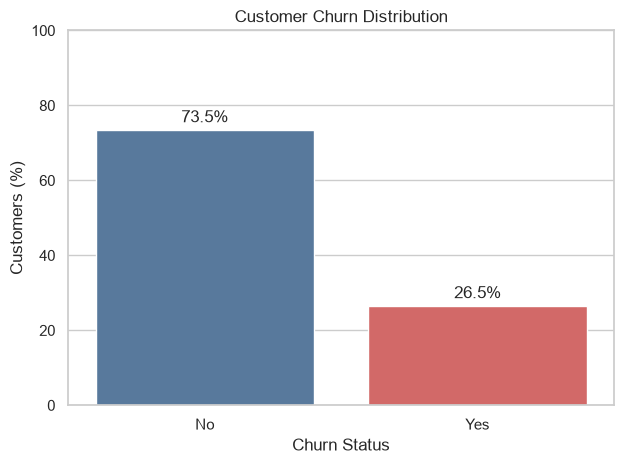

In [6]:
# Calculate the percentage of 'Yes' and 'No' data
# and place them in a dataframe layout for creating the chart
churn_distribution = (
    df["Churn"]
    .value_counts(normalize=True) 
    .mul(100)
    .reindex(["No", "Yes"])
    .rename_axis("Churn")
    .reset_index(name="Percentage")
)
display(churn_distribution.round(2))

# Pass the chart data to create using seaborn
# and configrue the chart axis using ax object
ax = sns.barplot(
    data=churn_distribution,
    x="Churn",
    y="Percentage",
    hue="Churn",
    palette=churn_palette,
    legend=False
)

# Configure each bar label
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
)

# Set axis labels
ax.set(
    title="Customer Churn Distribution",
    xlabel="Churn Status",
    ylabel="Customers (%)",
    ylim=(0, 100)
)

plt.tight_layout()
plt.show()


#### Key insight

Of the 7,043 customers, 26.54% churned and 73.46% remained. Churners are therefore the minority class, at roughly one churned customer for every 2.8 retained customers.

This moderate class imbalance means accuracy alone could be misleading: a model may appear successful while failing to identify many churners. Recall, precision, F1-score, and the confusion matrix will need to be used to evaluate the model.

### 2. Missing-value validation

After cleaning, check every column for both standard missing values and empty strings.

In [7]:
# Detect regular missing values 
missing_values = df.isna().sum()

# Detect empty strings
text_columns = df.select_dtypes(include="str").columns

blank_values = df[text_columns].apply(
    lambda column: column.str.strip().eq("").sum()
)

missing_summary = pd.DataFrame({
    "Missing values": missing_values,
    "Blank strings": blank_values
}).fillna(0).astype(int)

display(missing_summary[
    missing_summary.sum(axis=1) > 0
])


,Missing values,Blank strings


No missing values or blank strings remain after cleaning. The dataset is complete and ready for exploratory analysis.

### 3. Tenure and churn

Compare customer tenure for churned and retained customers to determine whether churn is concentrated at a particular stage of the customer lifecycle.

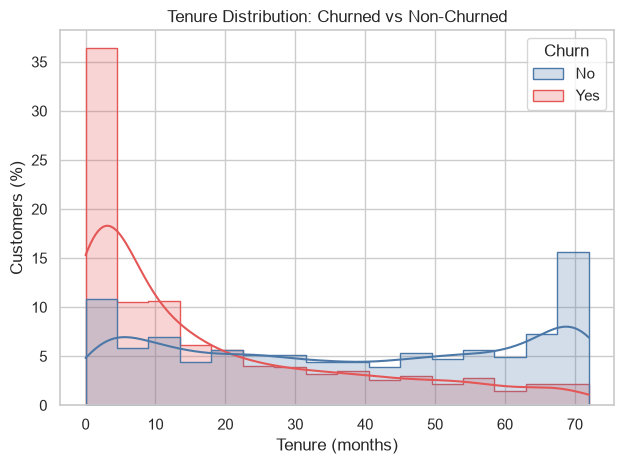

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5174.0,37.57,24.11,0.0,15.0,38.0,61.0,72.0
Yes,1869.0,17.98,19.53,1.0,2.0,10.0,29.0,72.0


In [8]:
ax = sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    palette=churn_palette,
    kde=True,
    element="step",
    stat="percent",
    common_norm=False
)

ax.set(
    title="Tenure Distribution: Churned vs Non-Churned",
    xlabel="Tenure (months)",
    ylabel="Customers (%)"
)

plt.tight_layout()
plt.show()

tenure_by_churn = df.groupby("Churn")["tenure"].describe()
tenure_by_churn.round(2)

#### Key insight

Customers who churned generally had much shorter tenures. Their average tenure was 17.98 months and their median was 10 months, compared with 37.57 months and 38 months for customers who did not churn. 

The separation is also visible across the distributions: 75% of churned customers had been subscribed for 29 months or less, whereas the corresponding threshold for retained customers was 61 months. Churn is therefore concentrated earlier in the customer lifecycle, making onboarding and early-tenure engagement important areas for retention efforts.

### 4. Contract type and churn

Compare churn rates across month-to-month, one-year, and two-year contracts.

,Contract,Churn Rate
0,Month-to-month,42.71
1,One year,11.27
2,Two year,2.83


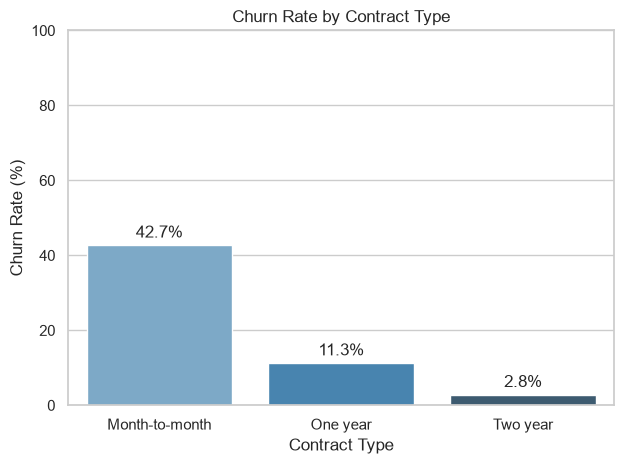

In [9]:
contract_churn_rates = (
    df.groupby("Contract")["Churn"]
    .value_counts(normalize=True)
    .xs("Yes", level="Churn")
    .mul(100)
    .reindex(["Month-to-month", "One year", "Two year"])
    .rename_axis("Contract")
    .reset_index(name="Churn Rate")
)
display(contract_churn_rates.round(2))

ax = sns.barplot(
    data=contract_churn_rates,
    x="Contract",
    y="Churn Rate",
    hue="Contract",
    palette="Blues_d",
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

ax.set(
    title="Churn Rate by Contract Type",
    xlabel="Contract Type",
    ylabel="Churn Rate (%)",
    ylim=(0, 100)
)

plt.tight_layout()
plt.show()

#### Key insight

Month-to-month customers have the highest churn rate at 42.71%, compared with 11.27% for one-year contracts and 2.83% for two-year contracts. That is a difference of 31.44 percentage points versus one-year contracts and 39.88 points versus two-year contracts.

The strong gradient suggests that longer commitments are associated with greater retention. However, contract type may also reflect customer tenure, pricing, or self-selection, so the relationship should not be interpreted as causal without further analysis.

### 5. Internet service and churn

How does churn vary among DSL, fiber-optic, and non-internet customers?

,Internet Service,Churn Rates
0,DSL,18.96
1,Fiber optic,41.89
2,No,7.40


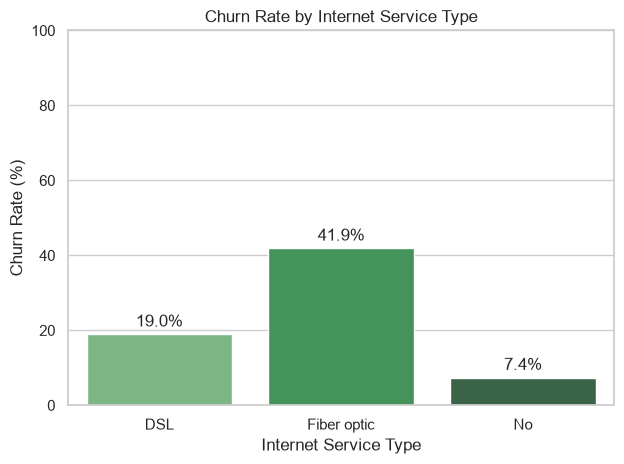

In [10]:
internet_churn_rates = (
    df.groupby("InternetService")["Churn"]
    .value_counts(normalize=True)
    .xs("Yes", level="Churn")
    .mul(100)
    .reindex(["DSL", "Fiber optic", "No"])
    .rename_axis("Internet Service")
    .reset_index(name="Churn Rates")
)
display(internet_churn_rates.round(2))

ax = sns.barplot(
    data=internet_churn_rates,
    x="Internet Service",
    y="Churn Rates",
    hue="Internet Service",
    palette="Greens_d",
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

ax.set(
    title="Churn Rate by Internet Service Type",
    xlabel="Internet Service Type",
    ylabel="Churn Rate (%)",
    ylim=(0,100)
)

plt.tight_layout()
plt.show()



#### Key insight

Internet service type has a noticeable relationship with churn. Fiber optic customers have the highest churn rate at 41.89%, followed by DSL customers at 18.96%. Customers without internet service have the lowest churn rate at 7.40%. 

The fiber-optic churn rate is 22.93 percentage points higher than DSL and 34.49 points higher than no internet service. This makes fiber-optic customers a high-priority segment for deeper investigation into price, service quality, contract mix, and support experience. The result is an association and does not establish that fiber service itself causes churn.

### 6. Payment method and churn

Compare churn rates across payment methods and identify the highest-risk group.

,Payment Method,Churn Rates
0,Bank transfer (automatic),16.71
1,Credit card (automatic),15.24
2,Electronic check,45.29
3,Mailed check,19.11


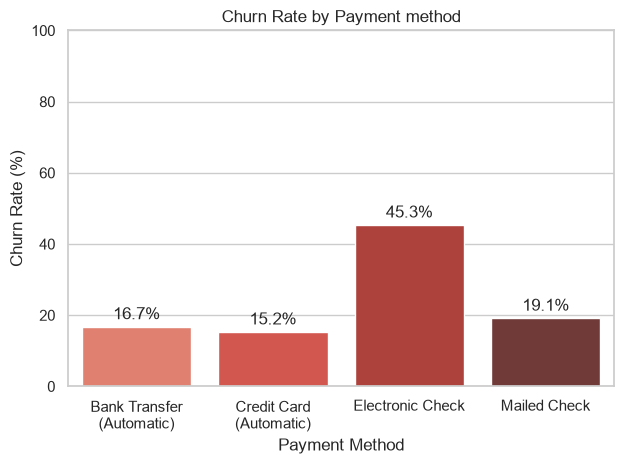

In [11]:
payment_churn_rates = (
    df.groupby("PaymentMethod")["Churn"]
    .value_counts(normalize=True)
    .xs("Yes", level="Churn")
    .mul(100)
    .reindex(["Bank transfer (automatic)", "Credit card (automatic)", "Electronic check", "Mailed check"])
    .rename_axis("Payment Method")
    .reset_index(name="Churn Rates")
)
display(payment_churn_rates.round(2))

ax = sns.barplot(
    data=payment_churn_rates,
    x="Payment Method",
    y="Churn Rates",
    hue="Payment Method",
    palette="Reds_d",
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

ax.set(
    title="Churn Rate by Payment method",
    xlabel="Payment Method",
    ylabel="Churn Rate (%)",
    ylim=(0, 100)
)

ax.set_xticks(
    ax.get_xticks(),
    ["Bank Transfer\n(Automatic)", "Credit Card\n(Automatic)",
    "Electronic Check", "Mailed Check"]
)

plt.tight_layout()
plt.show()

#### Key insight

Electronic-check customers have the highest churn rate at 45.29%. The rates for mailed check (19.11%), automatic bank transfer (16.71%), and automatic credit card (15.24%) are substantially lower.

Electronic check is therefore associated with a 26.18–30.05 percentage-point increase relative to the other methods. This group may overlap with month-to-month or paperless-billing customers, so multivariate analysis is needed before attributing the difference to payment method alone.

### 7. Monthly charges and churn

Compare average monthly charges for churned and retained customers.

,Churn,Average Monthly Charge
0,No,61.27
1,Yes,74.44


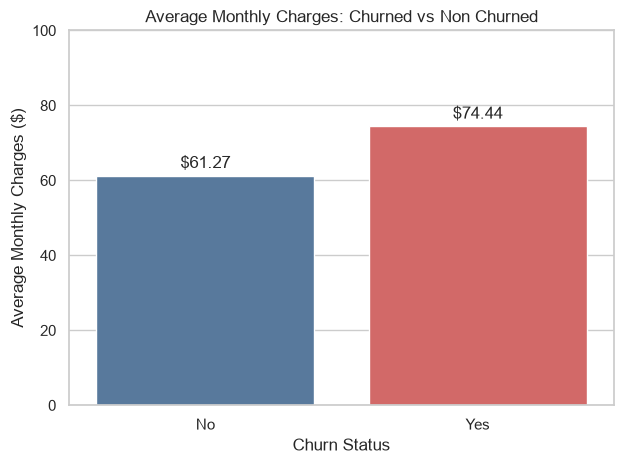

In [12]:
monthly_charges_av_by_churn = (
    df.groupby("Churn")["MonthlyCharges"]
    .mean()
    .rename_axis("Churn")
    .reset_index(name="Average Monthly Charge")
)
display(monthly_charges_av_by_churn.round(2))

ax= sns.barplot(
    data=monthly_charges_av_by_churn,
    x="Churn",
    y="Average Monthly Charge",
    hue="Churn",
    palette=churn_palette,
    legend=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="$%.2f",
        padding=3
    )

ax.set(
    title="Average Monthly Charges: Churned vs Non Churned",
    xlabel="Churn Status",
    ylabel="Average Monthly Charges ($)",
    ylim=(0, 100)
)

plt.tight_layout()
plt.show()


#### Key insight

Churned customers paid an average of $74.44 per month, compared with $61.27 for retained customers—a difference of approximately $13.18, or 21.5% relative to the retained-customer average.

Higher monthly charges are associated with churn, but the comparison does not control for service bundle, internet type, or contract. Those factors may explain part of the observed difference.

### 8. Online security, technical support, and churn

Do internet customers without online security or technical support churn more frequently than customers who subscribe to these services?

,Service,Status,Churn Rate
0,Online Security,Without,41.77
1,Online Security,No Internet Service,7.40
2,Online Security,With,14.61
3,Tech Support,Without,41.64
4,Tech Support,No Internet Service,7.40
5,Tech Support,With,15.17


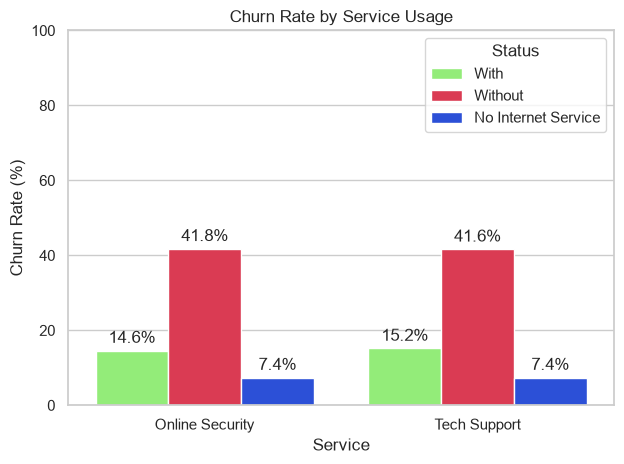

In [13]:
services = {"OnlineSecurity": "Online Security", "TechSupport": "Tech Support"}

services_churn = (
    pd.concat(
        {
            label: df.groupby(col)["Churn"]
                        .value_counts(normalize=True)
                        .xs("Yes", level="Churn")
                        .mul(100)
                        .rename({"Yes": "With", "No": "Without", "No internet service": "No Internet Service"})
            for col, label in services.items()
        },
        names=["Service", "Status"]
    )
    .rename("Churn Rate")
    .reset_index()
)
display(services_churn.round(2))

ax = sns.barplot(
    data=services_churn,
    x="Service",
    y="Churn Rate",
    hue="Status",
    hue_order=["With", "Without", "No Internet Service"],
    palette={"With": "#8f6", "Without": "#f52040", "No Internet Service": "#1040f3"}
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

ax.set(
    title="Churn Rate by Service Usage",
    xlabel="Service",
    ylabel="Churn Rate (%)",
    ylim=(0, 100)
)

plt.tight_layout()
plt.show()

#### Key insight

Among internet customers, those without online security churned at 41.77%, compared with 14.61% for subscribers—a gap of 27.16 percentage points. Similarly, customers without technical support churned at 41.64%, compared with 15.17% for subscribers—a gap of 26.47 points.

Both services are strongly associated with retention. They may also act as proxies for bundle depth, engagement, or customer needs, so controlled modeling is required before treating service enrollment as the direct cause.

### 9. Churn by tenure segment

Group customers by tenure to identify the lifecycle stage with the greatest retention risk.

,TenureGroup,Customers,Churned,ChurnRate
0,0-12,2186,1037,47.44
1,13-24,1024,294,28.71
2,25-48,1594,325,20.39
3,49+,2239,213,9.51


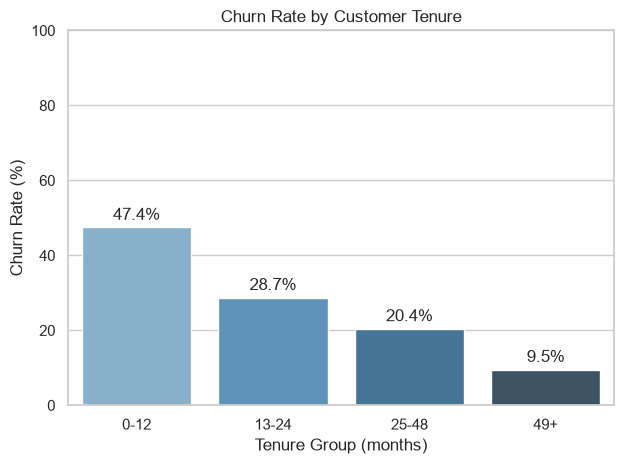

In [14]:
tenure_bins = [-1, 12, 24, 48, float("inf")]
tenure_labels = ["0-12", "13-24", "25-48", "49+"]

tenure_groups = pd.cut(
    df["tenure"],
    bins=tenure_bins,
    labels=tenure_labels
)

tenure_groups_churn = (
    df.assign(TenureGroup=tenure_groups)
    .groupby("TenureGroup", observed=False)["Churn"]
    .agg(
        Customers="size",
        Churned=lambda values: values.eq("Yes").sum(),
        ChurnRate=lambda values: values.eq("Yes").mean() * 100
    )
    .reset_index()
)
display(tenure_groups_churn.round(2))

ax = sns.barplot(
    data=tenure_groups_churn,
    x="TenureGroup",
    y="ChurnRate",
    hue="TenureGroup",
    palette="Blues_d",
    legend=False,
    dodge=False
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

ax.set(
    title="Churn Rate by Customer Tenure",
    xlabel="Tenure Group (months)",
    ylabel="Churn Rate (%)",
    ylim=(0, 100)
)

plt.tight_layout()
plt.show()

#### Key insight

The first-year segment has the highest churn rate at 47.44%. The rate declines consistently to 28.71% at 13–24 months, 20.39% at 25–48 months, and 9.51% after 49 months.

This monotonic pattern reinforces early tenure as the primary intervention window. Welcome journeys, proactive support, and first-year renewal offers are plausible retention initiatives to test.

### 10. Customer characteristics and churn

Examine how senior-citizen status, partner status, and dependent status are associated with churn.

,Status,Yes/No,Churn Rate
0,Senior Citizen,No,23.61
1,Senior Citizen,Yes,41.68
2,Partner,No,32.96
3,Partner,Yes,19.66
4,Dependents,No,31.28
5,Dependents,Yes,15.45


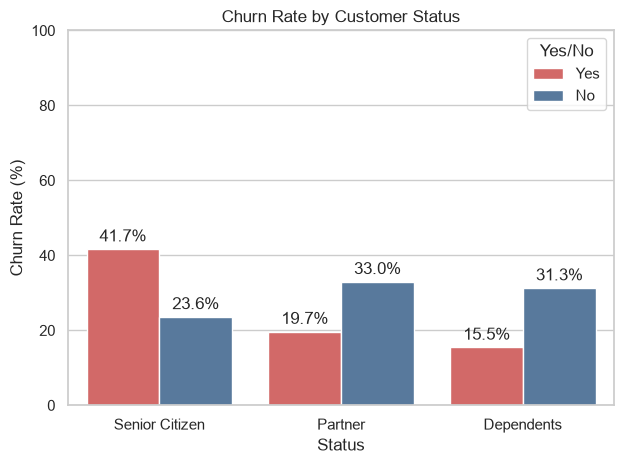

In [15]:
statuses = {"SeniorCitizen": "Senior Citizen", "Partner": "Partner", "Dependents": "Dependents"}

statuses_churn = (
    pd.concat(
        {
            label: df.groupby(col)["Churn"]
                        .value_counts(normalize=True)
                        .xs("Yes", level="Churn")
                        .mul(100)
            for col, label in statuses.items()
        },
        names=["Status", "Yes/No"]
    )
    .rename("Churn Rate")
    .reset_index()
)
display(statuses_churn.round(2))

ax = sns.barplot(
    data=statuses_churn,
    x="Status",
    y="Churn Rate",
    hue="Yes/No",
    hue_order=["Yes", "No"],
    palette=churn_palette
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3
    )

ax.set(
    title="Churn Rate by Customer Status",
    xlabel="Status",
    ylabel="Churn Rate (%)",
    ylim=(0, 100)
)

plt.tight_layout()
plt.show()

#### Key insight

Senior citizens had a higher churn rate at 41.68%, compared with 23.61% for non-senior customers. Customers without a partner also had a higher churn rate at 32.96%, compared with 19.66% for customers with a partner. Similarly, customers without dependents churned at 31.28%, compared with 15.45% for customers with dependents. 

These results identify senior citizens and customers without partners or dependents as higher-risk groups in this dataset. Demographic attributes should be used carefully: they may reflect differences in tenure, service mix, or support needs, and any operational use should be reviewed for fairness and appropriate customer treatment.

---

## Feature-level summary

### Categorical features

The following table compares churn rates across every category. It is a useful screening view for identifying potentially informative features, but it does not measure statistical significance, control for other variables, or prove causality.

In [16]:
categorical_columns = [
    column
    for column in df.select_dtypes(include="str").columns
    if column not in ["Churn"]
]

summary_tables = []

for column in categorical_columns:
    feature_summary = (
        df.groupby(column)["Churn"]
        .agg(
            ChurnRate=lambda values: values.eq("Yes").mean() * 100
        )
        .reset_index()
        .rename(columns={column: "Category"})
    )

    feature_summary.insert(0, "Feature", column)
    summary_tables.append(feature_summary)

categorical_churn_summary = pd.concat(
    summary_tables,
    ignore_index=True
)

display(categorical_churn_summary.round(2))


,Feature,Category,ChurnRate
0,gender,Female,26.92
1,gender,Male,26.16
2,SeniorCitizen,No,23.61
3,SeniorCitizen,Yes,41.68
4,Partner,No,32.96
5,Partner,Yes,19.66
6,Dependents,No,31.28
7,Dependents,Yes,15.45
8,PhoneService,No,24.93
9,PhoneService,Yes,26.71


The largest category-level differences appear in `Contract`, `PaymentMethod`, `InternetService`, `OnlineSecurity`, `TechSupport`, `OnlineBackup`, `DeviceProtection`, `SeniorCitizen`, `Partner`, `Dependents`, and `PaperlessBilling`. These variables are strong candidates for predictive modeling.

By contrast, `gender`, `PhoneService`, `MultipleLines`, `StreamingTV`, and `StreamingMovies` show smaller unadjusted differences. They should not be dropped solely on this basis: a feature with a weak bivariate relationship can still add value through interactions or after adjustment for correlated variables. Feature removal should be supported by cross-validation, regularization, permutation importance, or another multivariate method.

### Numerical features

Compare the distribution of each numerical variable between churned and retained customers using summary statistics and box plots.

tenure               MonthlyCharges               TotalCharges           \
        mean median    std           mean median    std         mean   median   
Churn                                                                           
No     37.57   38.0  24.11          61.27  64.43  31.09      2549.91  1679.52   
Yes    17.98   10.0  19.53          74.44  79.65  24.67      1531.80   703.55   

                
           std  
Churn           
No     2329.95  
Yes    1890.82

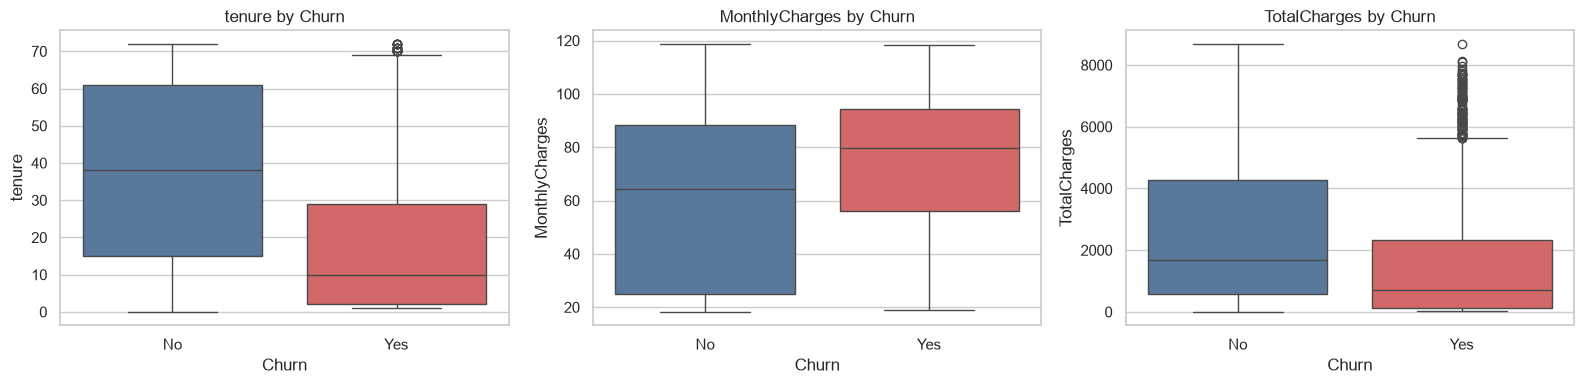

In [17]:
numerical_columns = [
    column
    for column in df.select_dtypes(exclude="str").columns
    if column not in ["Churn"]
]

numerical_churn_summary = (
    df.groupby("Churn")[numerical_columns]
    .agg([
        "mean",
        "median",
        "std"
    ])
    .round(2)
)

display(numerical_churn_summary)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(16, 4)
)

for axis, column in zip(axes, numerical_columns):
    sns.boxplot(
        data=df,
        x="Churn",
        y=column,
        hue="Churn",
        palette=churn_palette,
        legend=False,
        ax=axis
    )

    axis.set_title(f"{column} by Churn")

plt.tight_layout()
plt.show()

All three numerical variables show distributional differences between churned and retained customers and are reasonable modeling candidates. Churned customers have shorter tenure and higher monthly charges on average. Their lower `TotalCharges` is consistent with their much shorter tenure, so it should not be interpreted as evidence that lower cumulative spending causes churn.

Because `TotalCharges`, `tenure`, and `MonthlyCharges` are mechanically related, their joint contribution should be evaluated within the model rather than from isolated averages.

---

In [18]:
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    train_test_split
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

## Baseline churn model

A logistic-regression pipeline provides an interpretable baseline for predicting churn. All preprocessing is fitted inside the pipeline so that transformations learned from the training data are applied consistently during cross-validation and final testing.

In [19]:
# Create the feature table
X = df.drop(columns=["Churn"])

# Create the target
y = df["Churn"].map({
    "No": 0,
    "Yes": 1
})

### Feature and target definition

The target is encoded as `1` for churn and `0` for retention. Predictor columns are separated by data type so categorical and numerical features can receive the appropriate preprocessing.

In [20]:
# Get categorical features
categorical_features = (
    X
    .select_dtypes(include="str")
    .columns
    .tolist()
)


numeric_features = [
    column
    for column in X.columns
    if column not in categorical_features 
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numeric_features)

Categorical features:
['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']

Numerical features:
['tenure', 'MonthlyCharges', 'TotalCharges']


### Train–test split

The data is split into an 80% training set and a 20% holdout test set. Stratification preserves the original churn rate in both partitions, while `random_state=42` makes the split reproducible. The test set remains untouched until the final evaluation.

In [21]:
# Keep 20% completely untouched for the final testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Test rows:", len(X_test))

print("\nTraining churn distribution:")
print(
    y_train
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

print("\nTest churn distribution:")
print(
    y_test
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

Training rows: 5634
Test rows: 1409

Training churn distribution:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64

Test churn distribution:
Churn
0    73.46
1    26.54
Name: proportion, dtype: float64


### Preprocessing

Categorical variables are one-hot encoded, with previously unseen categories ignored safely at prediction time. Numerical variables are rescaled to the 0–1 range so the logistic-regression regularization treats their coefficient magnitudes comparably.

In [22]:
preprocessor = ColumnTransformer([
    (
        "categorical",
        OneHotEncoder(handle_unknown="ignore"),
        categorical_features
    ),
    (
        "numeric",
        MinMaxScaler(),
        numeric_features
    )
])

### Modeling pipeline

The preprocessing steps and logistic-regression classifier are combined into one pipeline. This design reduces data-leakage risk because every cross-validation fold learns its encodings and scaling parameters from that fold's training portion only.

In [23]:
logistic_pipeline = Pipeline([
    (
        "preprocess",
        preprocessor
    ),
    (
        "model",
        LogisticRegression(
            solver="liblinear",
            max_iter=1000,
            random_state=42
        )
    )
])

### Cross-validation strategy

Five-fold stratified cross-validation estimates performance across multiple train–validation partitions while preserving the churn proportion in each fold. Shuffling with a fixed random seed improves reproducibility.

In [24]:
# Splits training set for validation with shuffled combinations
cross_validation = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

### Hyperparameter search space

The search compares regularization strengths and class-weighting schemes. Class weighting changes the penalty assigned to errors on churned versus retained customers, allowing the model to prioritize the minority class.

In [25]:
logistic_parameter_grid = {
    # controls regularization
    # smaller -> more regularization
    "model__C": [
        0.01,
        0.1,
        1,
        10
    ],
    "model__l1_ratio": [
        0.0, 
        1.0
    ],
    # Changes the importance the model places on Churners(1) and Non-Churners(0)
    "model__class_weight": [
        None,
        "balanced",
        {0: 1, 1: 1.5},
        {0: 1, 1: 2},
        {0: 1, 1: 3}
    ]
}

### Model selection

Grid search evaluates every parameter combination using churn recall as the selection metric. This prioritizes identifying as many actual churners as possible, which is appropriate when the cost of overlooking an at-risk customer is higher than the cost of contacting a customer who would have stayed.

In [26]:
# Trains model with all parameter combinations to chose
# the parameters with the best score (recall)
logistic_search = GridSearchCV(
    estimator=logistic_pipeline,
    param_grid=logistic_parameter_grid,
    scoring="recall",
    cv=cross_validation,
    n_jobs=-1,
    verbose=1
)

logistic_search.fit(
    X_train, 
    y_train
)

Fitting 5 folds for each of 40 candidates, totalling 200 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...liblinear'))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced', ...], 'model__l1_ratio': [0.0, 1.0]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`s

### Test performance

The best cross-validated pipeline is evaluated once on the untouched test set. The classification report presents class-specific precision, recall, and F1-score alongside overall accuracy.

In [27]:
logistic_model = logistic_search.best_estimator_

logistic_predictions = logistic_model.predict(
    X_test
)

print("Best parameters:")
print(logistic_search.best_params_)

print("\nBest cross-validation recall:")
print(round(logistic_search.best_score_, 3))

print(classification_report(
    y_test, 
    logistic_predictions,
    target_names=["Stayed", "Churned"],
    digits=3
    ))

Best parameters:
{'model__C': 0.01, 'model__class_weight': {0: 1, 1: 3}, 'model__l1_ratio': 1.0}

Best cross-validation recall:
0.83
              precision    recall  f1-score   support

      Stayed      0.919     0.689     0.787      1035
     Churned      0.491     0.832     0.618       374

    accuracy                          0.727      1409
   macro avg      0.705     0.760     0.703      1409
weighted avg      0.805     0.727     0.742      1409



### Confusion matrix

The confusion matrix translates the evaluation metrics into customer counts, showing how many churners were detected or missed and how many retained customers were incorrectly flagged.

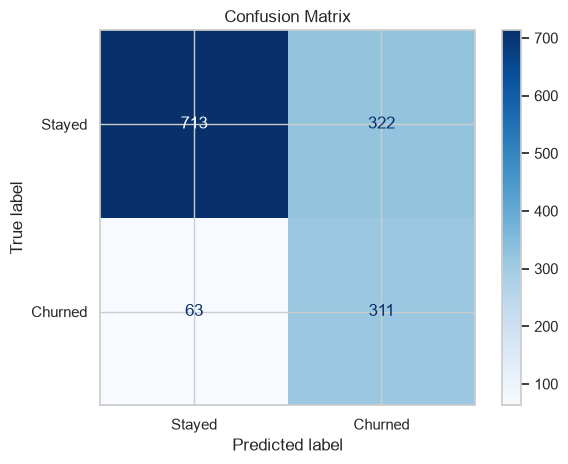

In [28]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_predictions,
    labels=[0, 1],
    display_labels=["Stayed", "Churned"],
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

## Model interpretation and next steps

Based on the saved holdout output, the model identifies 83.2% of actual churners, which aligns with the recall-focused objective. Churn precision is 49.1%, meaning that approximately half of the customers flagged as likely to churn are false positives. Overall accuracy is 72.7%, but it is not the primary success measure for this imbalanced dataset.

Whether this trade-off is acceptable depends on campaign economics:

- If outreach is inexpensive and missing a churner is costly, the current high-recall model may be appropriate.
- If outreach or incentives are expensive, the decision threshold and selection metric should be adjusted to improve precision or expected profit, accepting that more churners may be missed.

---

## Decision-tree classifier

A decision tree is evaluated as a nonlinear alternative to logistic regression. It can learn threshold-based rules and interactions between customer attributes without requiring those relationships to be specified in advance. The same training split, cross-validation folds, preprocessing, and recall-focused objective are retained to support a fair comparison between models.

### Modeling pipeline

The decision tree is combined with the existing preprocessor in a single pipeline, preventing information from the validation folds from influencing preprocessing. One-hot encoding is still required for categorical variables; numerical scaling is not necessary for a tree, but retaining the shared preprocessor keeps the model comparison consistent. A fixed random seed makes the tree reproducible.

In [29]:
from sklearn.tree import DecisionTreeClassifier

tree_pipeline = Pipeline([
    (
        "preprocess",
        preprocessor
    ),
    (
        "model",
        DecisionTreeClassifier(
            random_state=42
        )
    )
])

### Hyperparameter search space

The search tunes three parameters that control model complexity and sensitivity to churners:

- `max_depth` limits the number of decision levels and reduces the risk of an overly complex tree.
- `min_samples_leaf` requires each terminal leaf to contain a minimum number of customers, producing more stable rules.
- `class_weight` increases the cost of misclassifying churners, encouraging higher churn recall.

The grid deliberately tests shallow, regularized trees because an unrestricted decision tree can memorize training patterns and generalize poorly.

In [30]:
tree_parameter_grid = {
    "model__max_depth": [
        5,
        6,
        7,
        8
    ],
    "model__min_samples_leaf": [
        5, 
        10,
        15,
        20
    ],
    "model__class_weight": [
        "balanced",
        {0: 1, 1: 3},
        {0: 1, 1: 4}
    ]
}

### Model selection

Grid search evaluates 48 parameter combinations using the same five-fold stratified cross-validation strategy as the logistic-regression baseline. Churn recall remains the selection metric, reflecting the objective of minimizing missed at-risk customers.

In [31]:
tree_search = GridSearchCV(
    estimator=tree_pipeline,
    param_grid=tree_parameter_grid,
    scoring="recall",
    cv=cross_validation,
    n_jobs=-1,
    verbose=1
)

tree_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 48 candidates, totalling 240 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__class_weight': ['balanced', {0: 1, 1: 3}, ...], 'model__max_depth': [5, 6, ...], 'model__min_samples_leaf': [5, 10, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metrice

### Test performance

The best cross-validated tree is evaluated on the untouched test set. Its selected depth and number of leaves provide a direct indication of model complexity, while the classification report measures the trade-off between identifying churners and incorrectly flagging retained customers.

In [32]:
tree_model = tree_search.best_estimator_

tree_predictions = tree_model.predict(
    X_test
)

print("Best decision-tree parameters:")
print(tree_search.best_params_)

print("\nBest cross-validation recall:")
print(round(tree_search.best_score_, 3))

selected_tree = tree_model.named_steps["model"]

print("Tree depth:", selected_tree.get_depth())
print("Number of leaves:", selected_tree.get_n_leaves())

print(
    classification_report(
        y_test,
        tree_predictions,
        target_names=[
            "Stayed",
            "Churned"
        ],
        digits=3
    )
)

Best decision-tree parameters:
{'model__class_weight': {0: 1, 1: 4}, 'model__max_depth': 6, 'model__min_samples_leaf': 15}

Best cross-validation recall:
0.849
Tree depth: 6
Number of leaves: 57
              precision    recall  f1-score   support

      Stayed      0.916     0.693     0.789      1035
     Churned      0.492     0.824     0.616       374

    accuracy                          0.727      1409
   macro avg      0.704     0.758     0.702      1409
weighted avg      0.803     0.727     0.743      1409



### Confusion matrix

The confusion matrix presents the decision tree's predictions as customer counts. This makes the operational cost of false negatives (missed churners) and false positives (unnecessary retention contacts) easier to assess.

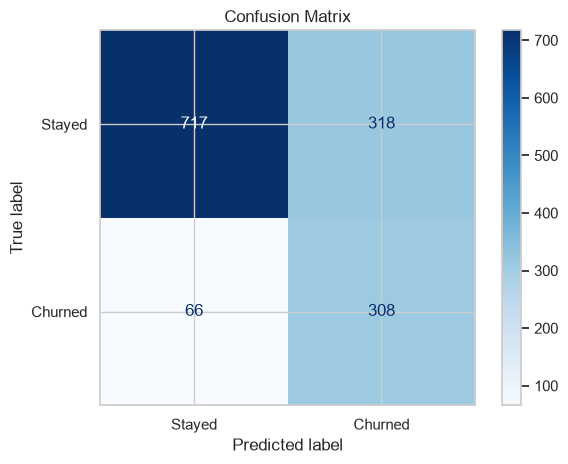

In [33]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    tree_predictions,
    labels=[0, 1],
    display_labels=["Stayed", "Churned"],
    cmap="Blues",
    values_format="d"
)

plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

### Decision-tree interpretation and model comparison

The selected tree uses a maximum depth of 6, a minimum of 15 customers per leaf, and a 4:1 error weight for churners. It contains 57 leaves, indicating that it captures substantially more segmented decision rules than logistic regression.

On the testing data, the tree identifies 82.4% of actual churners with 49.2% precision and 72.7% overall accuracy.

The tree does not improve on the logistic-regression baseline: churn recall is 0.8 percentage points lower (82.4% versus 83.2%), precision is effectively unchanged (49.2% versus 49.1%), and both models achieve 72.7% accuracy. Its cross-validation recall of 84.9% also falls to 82.4% on the holdout set, suggesting a generalization gap.

---

## Random-forest classifier

A random forest is evaluated to determine whether an ensemble of decision trees can improve churn detection. Each tree is trained ond sample and considers a random subset of features when splitting, which generally reduces the variance and overfitting risk of a single decision tree. The same data split, preprocessing, cross-validation folds, and recall-focused objective are retained for comparability with the previous models.

### Modeling pipeline

The random forest is placed inside the existing preprocessing pipeline so that categorical encoding is learned independently within each cross-validation fold. As with the decision tree, numerical scaling is not required by the model, but retaining the shared preprocessor ensures a consistent comparison.

In [34]:
from sklearn.ensemble import RandomForestClassifier

forest_pipeline = Pipeline([
    (
        "preprocess",
        preprocessor
    ),
    (
        "model",
        RandomForestClassifier(
            random_state=42
        )
    )
])

### Hyperparameter search space

The search tunes four parameters that affect ensemble stability, tree complexity, and sensitivity to churners:

- `n_estimators` controls the number of trees. More trees generally produce more stable predictions but increase training and prediction cost.
- `max_depth` limits the complexity of each tree and helps prevent overfitting.
- `min_samples_leaf` requires each terminal leaf to represent a minimum number of customers, smoothing highly specific rules.
- `class_weight` increases the cost of missing churners. `balanced_subsample` recalculates automatic class weights separately for each bootstrap sample.

The grid evaluates 108 combinations and favors relatively shallow trees, using the ensemble to capture diverse patterns rather than relying on deeply fitted individual trees.

In [35]:
forest_parameter_grid = {
    "model__n_estimators": [
        100,
        200,
        300
    ],
    "model__max_depth": [
        4,
        5,
        6
    ],
    "model__min_samples_leaf": [
        5,
        10,
        15
    ],
    "model__class_weight": [
        "balanced",
        "balanced_subsample",
        {0: 1, 1: 3},
        {0: 1, 1: 3.5}
    ]
}

### Model selection

Grid search evaluates all parameter combinations with five-fold stratified cross-validation. Churn recall remains the optimization metric, allowing the random forest to be compared directly with logistic regression and the single decision tree under the same retention objective.

In [36]:
forest_search = GridSearchCV(
    estimator=forest_pipeline,
    param_grid=forest_parameter_grid,
    scoring="recall",
    cv=cross_validation,
    n_jobs=-1,
    verbose=1
)

forest_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__class_weight': ['balanced', 'balanced_subsample', ...], 'model__max_depth': [4, 5, ...], 'model__min_samples_leaf': [5, 10, ...], 'model__n_estimators': [100, 200, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring

### Test performance

The best cross-validated forest is evaluated on the untouched test set. The classification report determines whether the ensemble's increase in churn recall is accompanied by acceptable precision and overall classification performance.

In [37]:
forest_model = forest_search.best_estimator_

forest_predictions = forest_model.predict(
    X_test
)

print("Best random-forest parameters:")
print(forest_search.best_params_)

print("\nBest cross-validation recall:")
print(round(forest_search.best_score_, 3))

print(
    classification_report(
        y_test,
        forest_predictions,
        target_names=[
            "Stayed",
            "Churned"
        ],
        digits=3
    )
)

Best random-forest parameters:
{'model__class_weight': {0: 1, 1: 3.5}, 'model__max_depth': 5, 'model__min_samples_leaf': 10, 'model__n_estimators': 200}

Best cross-validation recall:
0.864
              precision    recall  f1-score   support

      Stayed      0.925     0.643     0.758      1035
     Churned      0.464     0.856     0.602       374

    accuracy                          0.699      1409
   macro avg      0.694     0.749     0.680      1409
weighted avg      0.802     0.699     0.717      1409



### Confusion matrix

The confusion matrix expresses random-forest performance as customer counts, making the additional churners detected and retained customers incorrectly flagged directly comparable with the earlier models.

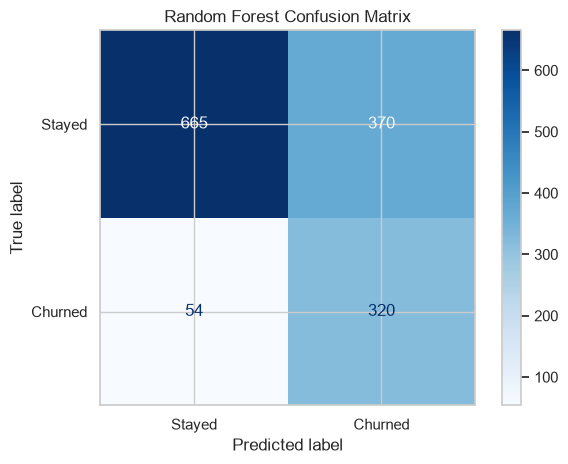

In [38]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    forest_predictions,
    labels=[0, 1],
    display_labels=[
        "Stayed",
        "Churned"
    ],
    cmap="Blues",
    values_format="d"
)

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

### Random-forest interpretation and model comparison

The selected forest contains 200 trees, each limited to a maximum depth of 5 with at least 10 customers per leaf. A 3.5:1 class weight penalizes missed churners more heavily than errors on retained customers. The best cross-validation recall is 86.4%, compared with 85.6% on the test set; the 0.8 percentage-point difference suggests good generalization.

On the test set, the random forest identifies 85.6% of actual churners with 46.4% precision and 69.9% overall accuracy. It correctly identifies 320 of 374 churners and misses 54, while incorrectly flagging 370 retained customers.

The forest achieves the highest churn recall of the three models: 2.4 percentage points above logistic regression and 3.2 points above the decision tree. This improvement comes at a cost. Compared with logistic regression, churn precision decreases by 2.7 points and accuracy decreases by 2.8 points. Operationally, the forest detects 9 additional churners but sends retention outreach to 48 additional customers who would have stayed. Its churn F1-score of 60.2% is also below logistic regression's 61.8%.